# Libraries

In [ ]:
#Anushka Poshattiwar
#PRN:23070521222

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

#load

In [ ]:
df = pd.read_csv("Housing.csv")

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


#Dimensions

In [ ]:
print(df.shape)

print(df.info())

print(df.isnull().sum())

(545, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestro

#Convert Categorical Columns to Numeric


In [ ]:
encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = encoder.fit_transform(df[column])

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


#Separate Features and Target

In [ ]:
X = df.drop("price", axis=1)

y = df["price"]

#Normalize Features

In [ ]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

#Train-Test Split (80:20)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(436, 12)
(109, 12)


#Model 1 (1 Hidden Layer)

In [ ]:
model1 = Sequential()

model1.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model1.add(Dense(1))

model1.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history1 = model1.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 25349389811712.0000 - mae: 4727422.0000 - val_loss: 24781600587776.0000 - val_mae: 4623898.0000
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 25349387714560.0000 - mae: 4727422.0000 - val_loss: 24781596393472.0000 - val_mae: 4623896.5000
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 25349383520256.0000 - mae: 4727422.0000 - val_loss: 24781594296320.0000 - val_mae: 4623896.5000
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 25349383520256.0000 - mae: 4727421.0000 - val_loss: 24781590102016.0000 - val_mae: 4623896.5000
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 25349377228800.0000 - mae: 4727421.0000 - val_loss: 24781585907712.0000 - val_mae: 4623896.0000
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 25349373034496.0000 - mae: 4727420.5000 - val_loss: 24781581713408.0000 - val_mae: 4623896.0000
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 25349373034496.0000 - 

#Prediction

In [ ]:
pred1 = model1.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


#Evaluation

In [ ]:
mae1 = mean_absolute_error(y_test, pred1)

mse1 = mean_squared_error(y_test, pred1)

rmse1 = np.sqrt(mse1)

print("MAE :", mae1)
print("MSE :", mse1)
print("RMSE:", rmse1)

MAE : 5007246.5
MSE : 30126129545216.0
RMSE: 5488727.497810034


#Model 2 (2 Hidden Layers)

In [ ]:
model2 = Sequential()

model2.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model2.add(Dense(32, activation='relu'))
model2.add(Dense(1))

model2.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model2.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 25349391908864.0000 - mae: 4727422.5000 - val_loss: 24781600587776.0000 - val_mae: 4623898.0000
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 25349387714560.0000 - mae: 4727421.5000 - val_loss: 24781594296320.0000 - val_mae: 4623896.5000
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 25349381423104.0000 - mae: 4727421.0000 - val_loss: 24781590102016.0000 - val_mae: 4623896.0000
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 25349373034496.0000 - mae: 4727420.5000 - val_loss: 24781579616256.0000 - val_mae: 4623895.5000
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 25349364645888.0000 - mae: 4727419.5000 - val_loss: 24781567033344.0000 - val_mae: 4623894.5000
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 25349354160128.0000 - mae: 4727418.5000 - val_loss: 24781556547584.0000 - val_mae: 4623893.0000
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 25349333188608.0000 - 

#Evaluation

In [ ]:
pred2 = model2.predict(X_test)

mae2 = mean_absolute_error(y_test, pred2)

mse2 = mean_squared_error(y_test, pred2)

rmse2 = np.sqrt(mse2)

print("MAE :", mae2)
print("MSE :", mse2)
print("RMSE:", rmse2)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
MAE : 4986086.0
MSE : 29834518462464.0
RMSE: 5462098.357084391


#Model 3 (3 Hidden Layers)

In [ ]:
model3 = Sequential()

model3.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model3.add(Dense(64, activation='relu'))
model3.add(Dense(32, activation='relu'))
model3.add(Dense(1))

model3.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model3.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 25349389811712.0000 - mae: 4727422.5000 - val_loss: 24781594296320.0000 - val_mae: 4623896.5000
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 25349379325952.0000 - mae: 4727420.5000 - val_loss: 24781577519104.0000 - val_mae: 4623895.5000
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 25349356257280.0000 - mae: 4727418.5000 - val_loss: 24781546061824.0000 - val_mae: 4623891.5000
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 25349314314240.0000 - mae: 4727414.0000 - val_loss: 24781487341568.0000 - val_mae: 4623886.0000
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 25349232525312.0000 - mae: 4727406.5000 - val_loss: 24781378289664.0000 - val_mae: 4623875.0000
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 25349094113280.0000 - mae: 4727392.0000 - val_loss: 24781187448832.0000 - val_mae: 4623856.0000
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 253488382

#Evaluation

In [ ]:
pred3 = model3.predict(X_test)

mae3 = mean_absolute_error(y_test, pred3)

mse3 = mean_squared_error(y_test, pred3)

rmse3 = np.sqrt(mse3)

print("MAE :", mae3)
print("MSE :", mse3)
print("RMSE:", rmse3)

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
MAE : 2044366.375
MSE : 5657254690816.0
RMSE: 2378498.410934092


#Compare Models

In [ ]:
results = pd.DataFrame({
    "Model": [
        "1 Hidden Layer",
        "2 Hidden Layers",
        "3 Hidden Layers"
    ],
    "MAE": [
        mae1,
        mae2,
        mae3
    ],
    "MSE": [
        mse1,
        mse2,
        mse3
    ],
    "RMSE": [
        rmse1,
        rmse2,
        rmse3
    ]
})

print(results)

print("\nBest Model:\n")
print(results.loc[results['RMSE'].idxmin()])

             Model          MAE           MSE          RMSE
0   1 Hidden Layer  5007246.500  3.012613e+13  5.488727e+06
1  2 Hidden Layers  4986086.000  2.983452e+13  5.462098e+06
2  3 Hidden Layers  2044366.375  5.657255e+12  2.378498e+06

Best Model:

Model    3 Hidden Layers
MAE          2044366.375
MSE      5657254690816.0
RMSE      2378498.410934
Name: 2, dtype: object


#Predict a Sample House Price

In [ ]:
sample = X_test[0].reshape(1, -1)

prediction = model3.predict(sample)

print("Predicted Price:", prediction[0][0])

print("Actual Price:", y_test.iloc[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted Price: 887984.44
Actual Price: 4060000


#MAE Comparison

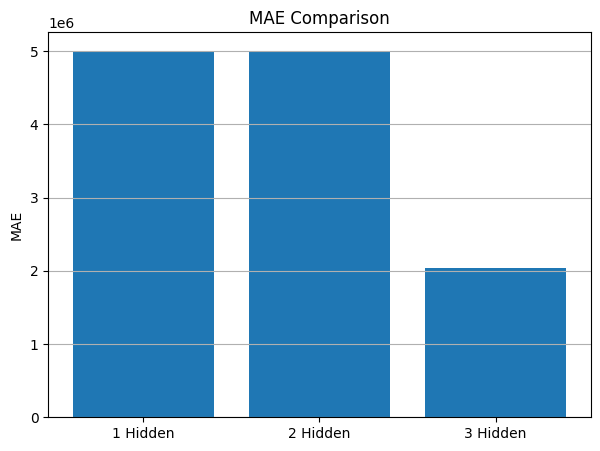

In [ ]:
import matplotlib.pyplot as plt

models = ['1 Hidden', '2 Hidden', '3 Hidden']
mae = [mae1, mae2, mae3]

plt.figure(figsize=(7,5))
plt.bar(models, mae)
plt.title("MAE Comparison")
plt.ylabel("MAE")
plt.grid(axis='y')
plt.show()

#RMSE Comparison

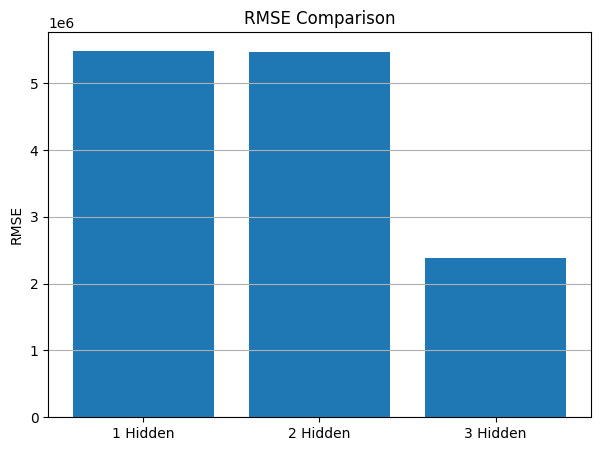

In [ ]:
rmse = [rmse1, rmse2, rmse3]

plt.figure(figsize=(7,5))
plt.bar(models, rmse)
plt.title("RMSE Comparison")
plt.ylabel("RMSE")
plt.grid(axis='y')
plt.show()

#MSE Comparison

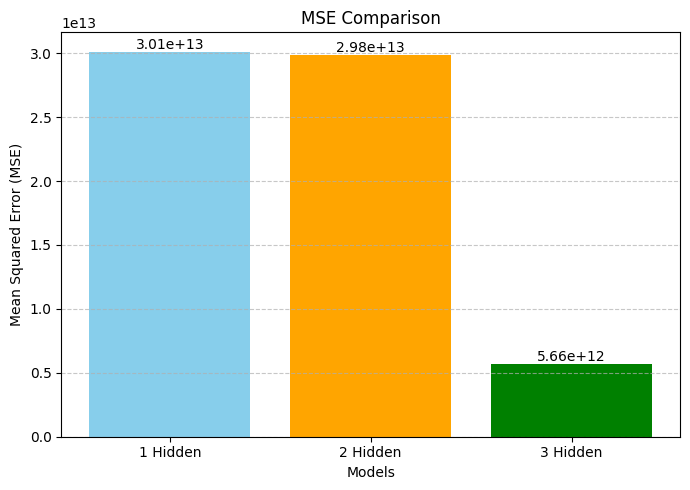

In [ ]:
import matplotlib.pyplot as plt

# MSE values
mse = [mse1, mse2, mse3]
models = ['1 Hidden', '2 Hidden', '3 Hidden']

plt.figure(figsize=(7,5))

plt.bar(models, mse, color=['skyblue', 'orange', 'green'])

plt.title("MSE Comparison")
plt.xlabel("Models")
plt.ylabel("Mean Squared Error (MSE)")

# Display values on top of bars
for i, value in enumerate(mse):
    plt.text(i, value, f'{value:.2e}', ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#Actual vs Predicted

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


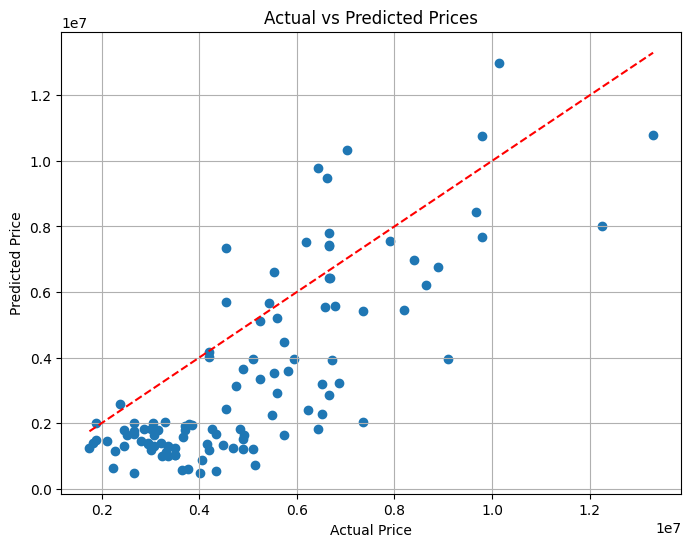

In [ ]:
pred = model3.predict(X_test)

plt.figure(figsize=(8,6))
plt.scatter(y_test, pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.grid(True)
plt.show()